In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.randn(200, 3) # X is going to be 200 3-dimensional vectors
y = 5 + 2*X[:, 0] - 3*X[:, 1] + 0.5*X[:, 2] + np.random.randn(200) * 0.5 # y = 5 + 2x1 - 3x2 + 0.5x3 + noise

In [ ]:
print(X.shape)
print(y.shape)

(200, 3)
(200,)


### Gradient Derivation for Multivariate Linear Regression

Now $X$ is a matrix of shape $(n, 3)$ — $n$ samples, each with $d$ features — and $w$ is a vector of shape $(3,)$. The prediction for sample $i$ is:

$$\hat{y}_i = \sum_{j=1}^{3} X_{ij} w_j + b = X_i \cdot w + b$$

Or for all samples at once: $\hat{y} = Xw + b$

The MSE loss is the same as before:

$$L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

### Derivative w.r.t. each $w_j$

Using the chain rule, the derivative w.r.t. a single weight $w_j$ is:

$$\frac{\partial L}{\partial w_j} = \frac{2}{n} \sum_{i=1}^{n} X_{ij} (\hat{y}_i - y_i)$$

This is just like the single-variable case, but using the $j$-th feature column $X_{ij}$ instead of a single $X_i$.

### Stacking into a vector

We want all $d$ partial derivatives at once. Stacking them gives a vector $\frac{\partial L}{\partial w}$ of shape $(3,)$:

$$\frac{\partial L}{\partial w} = \frac{2}{n} X^\top (\hat{y} - y)$$

**Why the transpose?** $X$ is $(n, 3)$ and `error` is $(n,)$. To get a result of shape $(3,)$, we need $X^\top$ which is $(3, n)$, then $X^\top \cdot \text{error}$ gives $(3,)$. The transpose lines up each feature column with the error vector, summing $X_{ij} \cdot \text{error}_i$ across all $n$ samples — exactly the formula above.

In code: `dw = (2/n) * X.T @ error`

### Derivative w.r.t. $b$

Same as before — $b$ shifts every prediction by the same amount regardless of features:

$$\frac{\partial L}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

In code: `db = (2/n) * np.sum(error)`

### Summary

The math is identical in spirit to single-variable regression — the only change is that $w$ is now a vector, and the per-feature sum is expressed compactly as $X^\top \cdot \text{error}$.

Epoch 0
Current weights: [ 83.42890931 -31.56509709   6.03913382], b = 77.7649
Current MSE: 12718.5147
Epoch 10
Current weights: [15.19472398 -3.92431176  1.30341137], b = 10.3694
Current MSE: 178.9934
Epoch 20
Current weights: [ 4.24268489 -2.96306962  0.79154815], b = 5.2772
Current MSE: 4.4658
Epoch 30
Current weights: [ 2.38834754 -2.96159043  0.6193196 ], b = 4.9853
Current MSE: 0.3815
Epoch 40
Current weights: [ 2.06118472 -2.9583172   0.57255022], b = 4.9964
Current MSE: 0.2575
Epoch 49
Current weights: [ 2.0041815  -2.95546184  0.56244981], b = 5.0054
Current MSE: 0.2534


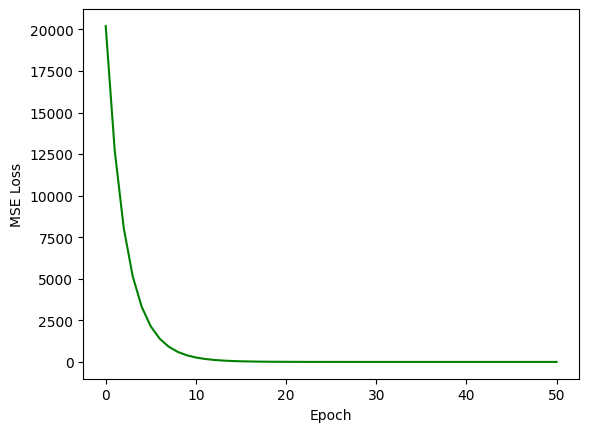

Final weights: [ 2.0041815  -2.95546184  0.56244981]
Final bias: 5.0054


In [ ]:
w = np.array([100, -42, 8]) # Start with random values
b = 99
gamma = 0.1

def compute_mse(X, y, w, b):
  # X has shape (200, 3), w has shape (3, 1) so X @ w outputs a (200, 1) array
  # containing our predictions
  y_pred = X @ w + b
  return np.mean((y_pred - y) ** 2)

def compute_gradients(X, y, w, b):
  n = len(X)
  y_pred = X @ w + b # Get the predictions array
  error = y_pred - y # Compare to actual y-values

  dw = (2/n) * X.T @ error # Derivative w.r.t to weights
  db = (2/n) * np.sum(error) # Derivative w.r.t to the bias

  return dw, db

steps_w = [w]
steps_b = [b]
losses = [compute_mse(X, y, w, b)]

for epoch in range(50):

  # Update values
  dw, db = compute_gradients(X, y, w, b)
  w = w - gamma * dw
  b = b - gamma * db

  loss = compute_mse(X, y, w, b)
  # Add to history
  steps_w.append(w)
  steps_b.append(b)
  losses.append(loss)

  if epoch % 10 == 0 or epoch == 49:
    print(f'Epoch {epoch}')
    print(f"Current weights: {w}, b = {b:.4f}")
    print(f"Current MSE: {loss:.4f}")

plt.plot(range(51), losses, color='green')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

print(f"Final weights: {w}")
print(f"Final bias: {b:.4f}")